# Описание датасета

В работе используется датасет Gaming and Mental Behavioral Dataset, представляющий собой синтетичекси сгенерированные данные о поведении игроков, их психическом состоянии, образе жизни и соицальной среде.

Выбор данного датасета обусловлен:
- большим объёмом данных
- наличием разнообразных признаков
- возможностью решения задачи классификации игровой зависимости

Исходный датасет содержит:
- 10000000 строк
- 40 признаков

Набор данных содержит переменные, сгруппированные в шесть основных областей.

1. Демографические характеристики
- age — Возраст участника
- gender — Категория пола
- income — Оценка ежемесячного дохода

2. Характеристики игрового поведения
- daily_gaming_hours — Среднее ежедневное время игры
- weekly_sessions — Количество игровых сессий в неделю
- years_gaming — Общее количество лет игрового опыта
- weekend_gaming_hours — Продолжительность игры в выходные
- multiplayer_ratio — Доля многопользовательской игры
- violent_games_ratio — Доля игр с насилием
- mobile_gaming_ratio — Доля мобильных игр
- night_gaming_ratio — Доля ночных игр
- competitive_rank — Соревновательный рейтинг навыков
- esports_interest — Интерес к участию в киберспорте
- streaming_hours — Еженедельное количество часов стриминга игр
- microtransactios_spending — Ежемесячные внутриигровые траты
- headset_usage — Использование гарнитуры

3. Характеристики психологического здоровья
- stress_level — Оценка воспринимаемого стресса
- anxiety_score — Оценка тревожности
- depression_score — Оценка депрессии
- addiction_level — Индикатор игровой зависимости
- loneliness_score — Индекс одиночества
- aggression_score — Оценка склонности к агрессии
- happiness_score — Общий уровень счастья

4. Характеристики социальной среды
- social_interaction_score — Индекс социальной активности
- relationship_satisfaction — Оценка качества отношений
- friends_gaming_count — Количество друзей, играющих в игры
- online_friends — Онлайн-социальные связи
- toxic_exposure — Подверженность токсичным сообществам
- parental_supervision — Оценка родительского контроля

5. Характеристики образа жизни
- sleep_hours — Средняя продолжительность сна
- exercise_hours — Еженедельное количество часов упражнений
- caffeine_intake — Ежедневное потребление кофеина
- screen_time_total — Общее ежедневное время перед экраном
- internet_quality — Качество интернет-соединения

6. Показатели физического здоровья
- bmi — Индекс массы тела
- eye_strain_score — Степень напряжения глаз
- back_pain_score — Степень боли в спине

7. Показатели продуктивности / эффективности
- academic_performance — Академическая успеваемость
- work_productivity — Продуктивность на рабочем месте

Так как исходная переменная addiction_level представлена в видде непрерывной шкалы от 0 до 10, она была преобразована в категориальный признак addiction_category (целевая переменная).

Для этого использовалось разбиение по квантилям (q=3), что похволило сформировать 3 класса: низкий, средний и высоский уровень игровой зависимости.

Такой подход обеспечивает баланс классов и повышает устойчивость модели.

In [36]:
from pathlib import Path

# корень проекта (поднимаемся на уровень выше notebooks)
BASE_DIR = Path().resolve().parent

# пути
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
IMAGES_DIR = BASE_DIR / "report" / "images"

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATA_RAW / "gaming_data.csv")

# создаём категориальный таргет
df['addiction_category'] = pd.qcut(
    df['addiction_level'],
    q=3,
    labels=['low', 'medium', 'high']
)

# проверяем баланс классов до сэмплирования
print("Before sampling:")
print(df['addiction_category'].value_counts(normalize=True))

# стратифицированная выборка
df_sample, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df['addiction_category'],
    random_state=42
)

df = df_sample.copy()

# проверяем баланс после
print("\nAfter sampling:")
print(df['addiction_category'].value_counts(normalize=True))

Before sampling:
addiction_category
medium    0.333655
low       0.333562
high      0.332783
Name: proportion, dtype: float64

After sampling:
addiction_category
medium    0.33366
low       0.33356
high      0.33278
Name: proportion, dtype: float64


Общая информация

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 896932 to 281278
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         50000 non-null  int64   
 1   gender                      50000 non-null  object  
 2   income                      50000 non-null  int64   
 3   daily_gaming_hours          50000 non-null  float64 
 4   weekly_sessions             50000 non-null  int64   
 5   years_gaming                50000 non-null  int64   
 6   sleep_hours                 50000 non-null  float64 
 7   caffeine_intake             50000 non-null  float64 
 8   exercise_hours              50000 non-null  float64 
 9   stress_level                50000 non-null  int64   
 10  anxiety_score               50000 non-null  float64 
 11  depression_score            50000 non-null  float64 
 12  social_interaction_score    50000 non-null  float64 
 13  relationship_sa

Разделение типов

In [39]:
# числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical features:")
print(num_cols)

print("\nCategorical features:")
print(cat_cols)

Numerical features:
Index(['age', 'income', 'daily_gaming_hours', 'weekly_sessions',
       'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
       'stress_level', 'anxiety_score', 'depression_score',
       'social_interaction_score', 'relationship_satisfaction',
       'academic_performance', 'work_productivity', 'addiction_level',
       'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio',
       'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours',
       'friends_gaming_count', 'online_friends', 'streaming_hours',
       'esports_interest', 'headset_usage', 'microtransactions_spending',
       'parental_supervision', 'loneliness_score', 'aggression_score',
       'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score',
       'back_pain_score', 'competitive_rank', 'internet_quality'],
      dtype='object')

Categorical features:
Index(['gender', 'addiction_category'], dtype='object')


Бинарные признаки

In [40]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

print("\nБинарные признаки:")
print(binary_cols)


Бинарные признаки:
['headset_usage']


In [41]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,35.969860,78004.944640,3.997298,20.130000,12.020640,7.006017,1.995442,2.002743,5.509320,4.993796,...,5.031240,5.012556,5.009905,5.984031,24.012296,8.003967,5.005440,4.009947,49.356660,5.502320
std,13.569834,41740.833397,2.825910,11.272336,7.221577,1.499408,1.997907,1.993824,2.868846,1.989024,...,3.155817,1.990245,1.972073,1.964596,3.999401,4.028967,1.978197,1.950940,28.854504,2.870596
min,13.000000,5004.000000,0.010000,1.000000,0.000000,1.010000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,7.320000,0.250000,0.000000,0.000000,0.000000,1.000000
25%,24.000000,42090.750000,1.920000,10.000000,6.000000,6.000000,0.580000,0.580000,3.000000,3.640000,...,2.000000,3.650000,3.650000,4.650000,21.300000,5.060000,3.660000,2.660000,24.000000,3.000000
50%,36.000000,78296.500000,3.350000,20.000000,12.000000,7.010000,1.380000,1.390000,6.000000,4.990000,...,5.000000,5.010000,5.010000,6.010000,24.020000,7.340000,5.010000,3.990000,50.000000,6.000000
75%,48.000000,114309.250000,5.380000,30.000000,18.000000,8.020000,2.760000,2.790000,8.000000,6.360000,...,8.000000,6.370000,6.350000,7.350000,26.690000,10.222500,6.340000,5.350000,74.000000,8.000000
max,59.000000,149993.000000,25.340000,39.000000,24.000000,13.180000,22.830000,24.380000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,39.790000,41.480000,10.000000,10.000000,99.000000,10.000000


# Полная очистка

Пропуски

In [42]:
# количество пропусков по каждому столбцу
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


Удаление дубликатов

In [43]:
print("До:", df.shape)

df = df.drop_duplicates()

print("После:", df.shape)

До: (50000, 40)
После: (50000, 40)


Приведение типов даных

In [44]:
# категориальные
df['gender'] = df['gender'].astype('category')

# бинарные
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

for col in binary_cols:
    df[col] = df[col].astype('category')

Выбросы (IQR)

In [45]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [46]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df = remove_outliers(df, col)

Работа с фичами: исходное количество, новые фичи, feature engineering

Исходное количество

In [47]:
print("Total features:", df.shape[1])
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Total features: 40
Numerical: 38
Categorical: 2


future engineering

In [48]:
# недельная игровая нагрузка (общее игровое время за неделю)
df['total_gaming_load'] = df['daily_gaming_hours'] * 5 + df['weekend_gaming_hours']

In [49]:
# интенсивность игрового поведения (частота * длительность = вовлеченность)
df['gaming_intensity'] = df['weekly_sessions'] * df['daily_gaming_hours']


In [50]:
# восстановление организма
df['recovery_score'] = df['sleep_hours'] + df['exercise_hours']

In [51]:
# физическая нагрузка
df['physical_strain'] = df['eye_strain_score'] + df['back_pain_score']

In [52]:
# средний уровень продуктивности
df['productivity_index'] = (
    df['academic_performance'] +
    df['work_productivity']
) / 2

 data leakage

Для предотвращения утечки данных были исключены признаки, напрямую описывающие уровень игровой зависимоти, а не ее причины.

In [53]:
cols = [
    'addiction_level',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'loneliness_score',
    'happiness_score',
    'aggression_score'
]

In [54]:
df = df.drop(columns=cols)

Итоговое количество признаков

In [55]:
# числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Total features:", df.shape[1])
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Total features: 38
Numerical: 35
Categorical: 3


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36763 entries, 896932 to 281278
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         36763 non-null  int64   
 1   gender                      36763 non-null  category
 2   income                      36763 non-null  int64   
 3   daily_gaming_hours          36763 non-null  float64 
 4   weekly_sessions             36763 non-null  int64   
 5   years_gaming                36763 non-null  int64   
 6   sleep_hours                 36763 non-null  float64 
 7   caffeine_intake             36763 non-null  float64 
 8   exercise_hours              36763 non-null  float64 
 9   social_interaction_score    36763 non-null  float64 
 10  relationship_satisfaction   36763 non-null  float64 
 11  academic_performance        36763 non-null  float64 
 12  work_productivity           36763 non-null  float64 
 13  multiplayer_rat

In [57]:
df.to_csv(DATA_PROCESSED / "cleaned.csv", index=False)

# Визуализации, графики, отражающие зависимости

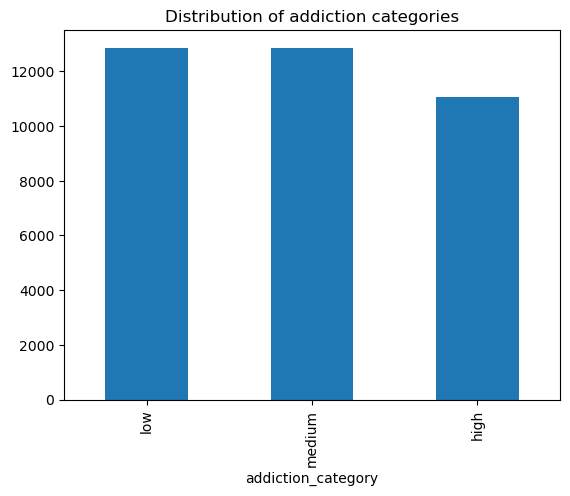

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

df['addiction_category'].value_counts().plot(kind='bar')
plt.title("Distribution of addiction categories")
plt.show()

Распределение целевой переменной показывает умеренный баланс классов, что позволяет обучать модель без дополнительного ресэмплинга.

Игровая нагрузка vs зависимость

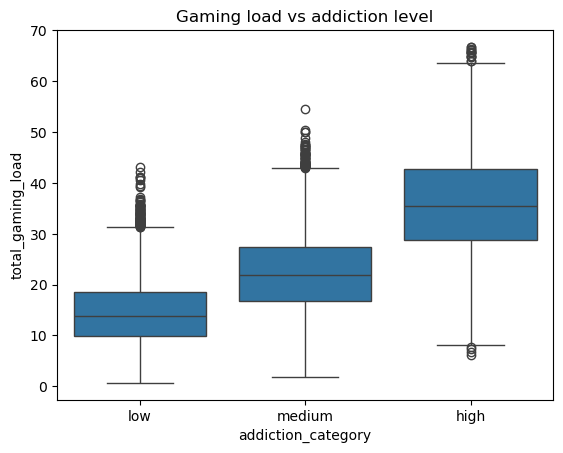

In [59]:
sns.boxplot(data=df, x='addiction_category', y='total_gaming_load')
plt.title("Gaming load vs addiction level")
plt.show()

Цифровая перегрузка vs зависимость

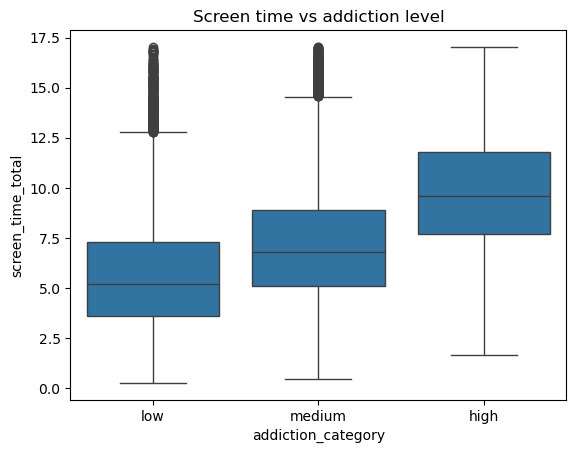

In [60]:
sns.boxplot(data=df, x='addiction_category', y='screen_time_total')
plt.title("Screen time vs addiction level")
plt.show()

Сон vs зависимость

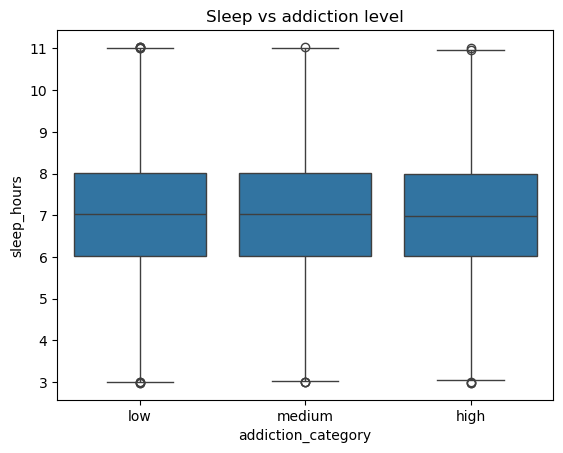

In [61]:
sns.boxplot(data=df, x='addiction_category', y='sleep_hours')
plt.title("Sleep vs addiction level")
plt.show()

Продуктивность vs зависимость

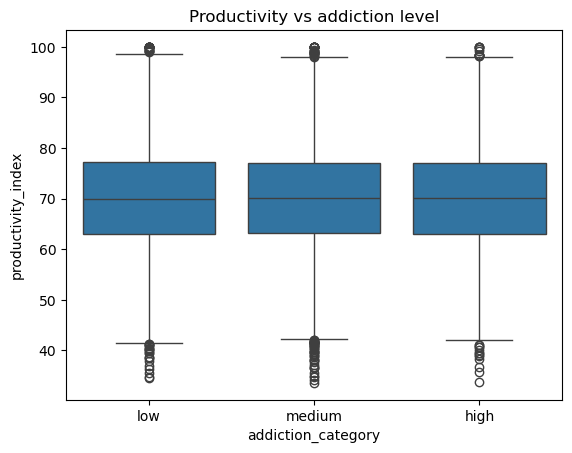

In [62]:
sns.boxplot(data=df, x='addiction_category', y='productivity_index')
plt.title("Productivity vs addiction level")
plt.show()

Корреляционная матрица

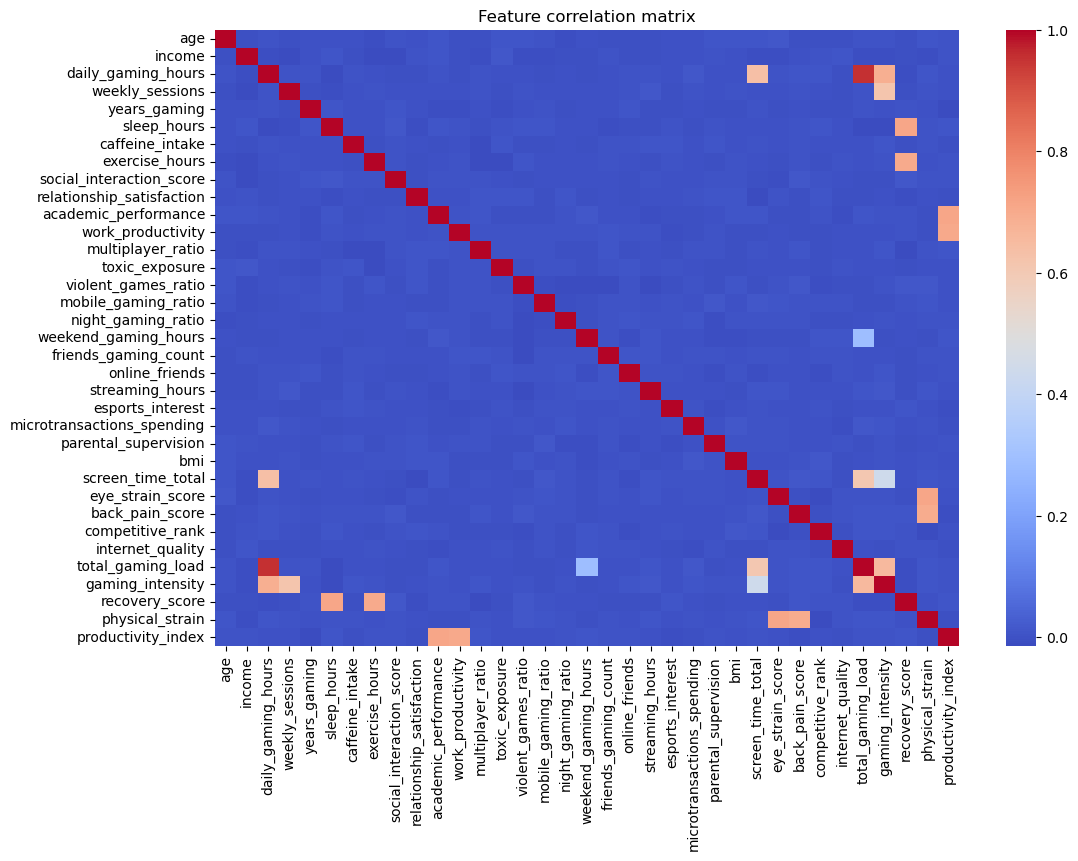

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature correlation matrix")
plt.show()

Социальная активность vs зависимость

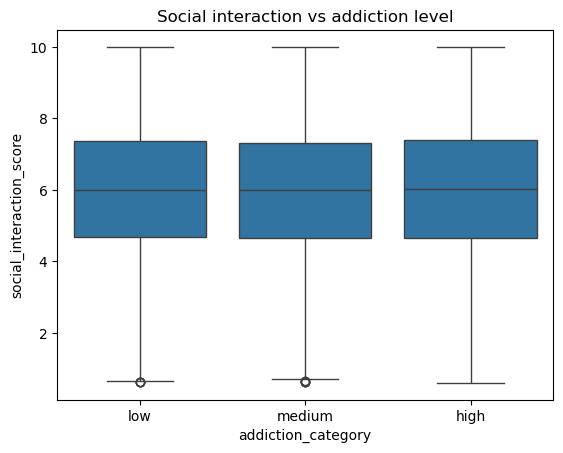

In [64]:
sns.boxplot(data=df, x='addiction_category', y='social_interaction_score')
plt.title("Social interaction vs addiction level")
plt.show()

Физическое состояние vs зависимость

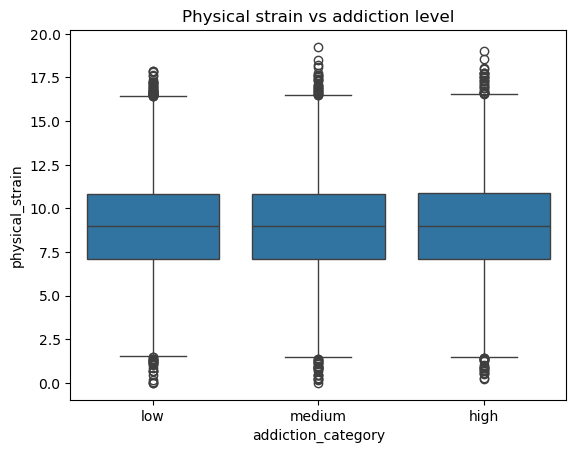

In [65]:
sns.boxplot(data=df, x='addiction_category', y='physical_strain')
plt.title("Physical strain vs addiction level")
plt.show()

Гистограмма игровых часов

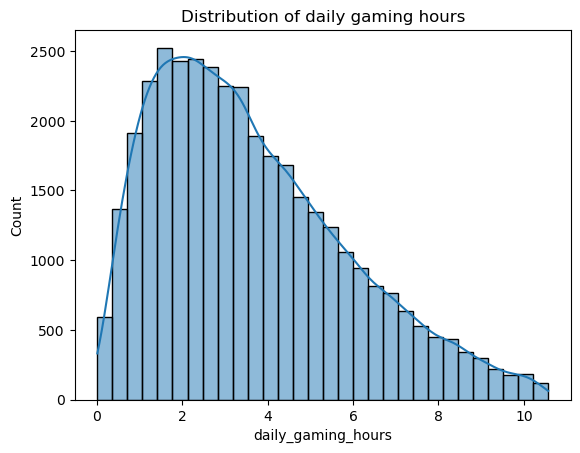

In [66]:
sns.histplot(df['daily_gaming_hours'], bins=30, kde=True)
plt.title("Distribution of daily gaming hours")
plt.show()

В рамках анализа данных были построены визуализации, отражающие зависимости между поведенческими, социальными и физическими характеристиками пользователей и уровнем игровой зависимости.
Результаты визуального анализа показали наличие устойчивых закономерностей между увеличением игровой и цифровой активности и ростом уровня зависимости.

# Корректный сплит (train/val/test) и пояснение как избегали даталика, если он мог быть как это сделать

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['addiction_category'])
y = df['addiction_category']

# One-hot для категориальных фич
X = pd.get_dummies(X, columns=['gender', 'headset_usage'], drop_first=True)

# 1) train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# 2) val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

Данные были разделены на обучающую, валидационную и тестовую выборки в соотношении 70/15/15 с использованием стратифицированного разбиения по целевой переменной для сохранения баланса классов.

Так как все признаки формировались на уровне отдельных наблюдений и не использовали агрегированные статистики по всему набору данных, риск утечки данных отсутствует.

# Выбор метрик качества и обоснование почему именно она. Если метрик несколько, то чему отдаем предпочтение.

Для оценки качества моделей использовались несколько метрик, учитывающих особенности задачи многоклассовой классификации.

Основной метрикой был выбран F1-score (macro), так как он учитывает баланс между точностью и полнотой для каждого класса и не зависит от распределения классов. Это особенно важно в задачах с несколькими уровнями зависимости (low, medium, high), где ошибки между соседними классами также имеют значение.

В качестве дополнительной метрики выбрана accuracy, отражающая общую долю верных предсказаний.

Также будет анализироваться confusion matrix, позволяющая оценить характер ошибок модели и выявить классы, которые чаще всего путаются.

# Моделирование и эксперименты 

1 эксперимент Random Forest Classifier

Обучение baseline модели

In [70]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


validation

In [71]:
from sklearn.metrics import f1_score, accuracy_score

val_pred = model.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred))
print("VAL F1 macro:", f1_score(y_val, val_pred, average='macro'))

VAL Accuracy: 0.6920565832426551
VAL F1 macro: 0.6952238665547398


Final test

In [72]:
y_pred = model.predict(X_test)

print("TEST Accuracy:", accuracy_score(y_test, y_pred))
print("TEST F1 macro:", f1_score(y_test, y_pred, average='macro'))

TEST Accuracy: 0.6908431550317317
TEST F1 macro: 0.6956292096316289


Confusion matrix

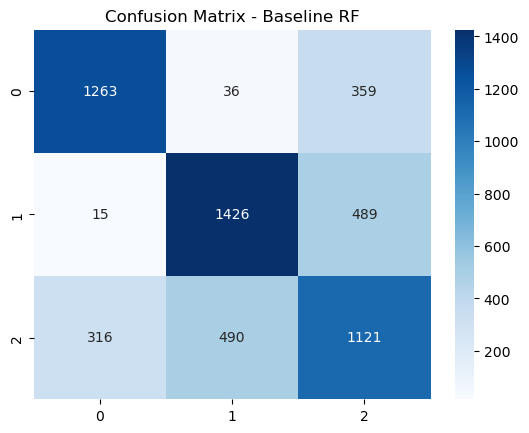

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline RF")
plt.show()

2 эксперимент Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# пайплайн: масштабирование + модель
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

c:\Users\kioko\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [75]:
y_pred_lr = log_reg.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("LOG REG Accuracy:", accuracy_score(y_test, y_pred_lr))
print("LOG REG F1 macro:", f1_score(y_test, y_pred_lr, average='macro'))

print(classification_report(y_test, y_pred_lr))

LOG REG Accuracy: 0.6922937443336356
LOG REG F1 macro: 0.6966940888885557
              precision    recall  f1-score   support

        high       0.79      0.76      0.78      1658
         low       0.73      0.75      0.74      1930
      medium       0.57      0.58      0.57      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.70      0.70      5515
weighted avg       0.69      0.69      0.69      5515



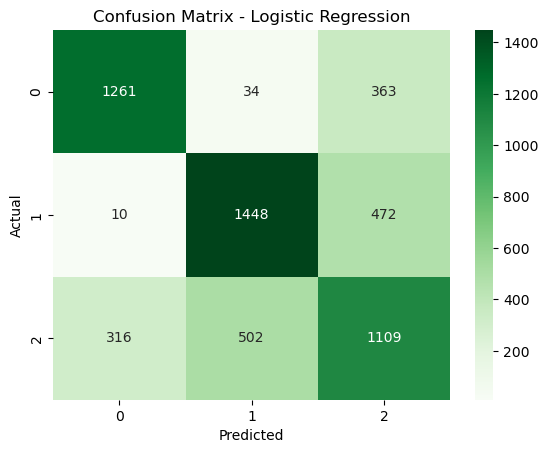

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Logistic Regression
Логистическая регрессия показала стабильные результаты на уровне F1 macro ≈ 0.697 и accuracy ≈ 0.692. Модель хорошо справляется с классификацией крайних классов (low и high), демонстрируя высокие значения precision и recall для этих категорий.

Наибольшие трудности наблюдаются при классификации класса medium, который имеет промежуточную природу и частично перекрывается с соседними классами. Это приводит к снижению качества именно на этом уровне.

Несмотря на свою линейную природу, модель показывает конкурентоспособный результат, что указывает на наличие достаточно линейных зависимостей между признаками и целевой переменной.

# Random Forest
Random Forest Classifier также показал стабильные результаты (F1 macro ≈ 0.696, accuracy ≈ 0.691), незначительно отличающиеся от Logistic Regression.

Модель демонстрирует хорошую способность к разделению классов low и high, однако также испытывает затруднения при различении среднего уровня зависимости.

Отсутствие значительного улучшения по сравнению с линейной моделью говорит о том, что сложные нелинейные зависимости в данных выражены слабо, либо уже достаточно хорошо описываются исходными признаками.

# Общий вывод
Сравнение двух baseline моделей — Logistic Regression и Random Forest — показало, что их качество практически идентично.

Это свидетельствует о том, что:
- признаки обладают высокой информативностью;
- зависимости между ними и целевой переменной в значительной степени линейны или слабо нелинейны;
- задача имеет квазинепрерывную природу, особенно в области класса medium, который является переходным состоянием между low и high.

Таким образом, усложнение модели не приводит к значительному улучшению качества, и основным ограничением является не модель, а природа разбиения целевой переменной.